# Introduction to DEA Fuel Moisture Content <img align="right" src="https://github.com/GeoscienceAustralia/dea-notebooks/raw/develop/Supplementary_data/dea_logo.jpg">

* **[Sign up to the DEA Sandbox](https://app.sandbox.dea.ga.gov.au/)** to run this notebook interactively from a browser
* **Compatibility:** Notebook currently compatible with the `DEA Sandbox` environment
* **Products used:** [DEA Fuel Moisture Content](https://knowledge.dea.ga.gov.au/data/product/) --> can either be linked to the knowledge hub data page or the DEA Explorer page***

## Background
Australia’s hot, dry climate and expansive bushland make it one of the most fire-prone regions in the world, where understanding vegetation dryness is critical for managing bushfire risk. 

One key measure used in this context is Fuel Moisture Content (FMC), which refers to the amount of water contained in vegetation, expressed as a percentage of its dry weight. FMC plays a vital role in fire management because it indicates how easily vegetation can ignite and sustain fire, as lower FMC levels mean drier, more flammable fuel.


### What this product offers
The Fuel Moisture Content (FMC) product communicates the moisture content of vegetation. It measures the percentage of water mass relative to dry mass in living vegetation. Values range from 0 – 300%, where 300 would mean there is three times as much water (by weight) than dry plant material. Vegetation moisture is a critical variable for understanding vegetation flammability and fire potential. Values between 0 – 150% are particularly relevant for fire behaviour analysis, as variations within this range are most strongly associated with changes in vegetation flammability and the likelihood of ignition.

FMC is derived from Sentinel 2A, 2B & 2C satellite imagery at a 20m resolution for all of Australia from 12 July 2015 to present. This product shows FMC values calculated for each pixel in the corresponding Sentinel-2 scene with applied masking cloud, cloud shadow, water and terrain shadow.


### Applications
* Monitoring and mapping the dryness of vegetation across different landscapes
* Predict and assess vegetation flammability and fire risk, spread and intensity
* Modelling fire risk over time and across different ecosystems with changing climate conditions
* Prioritise and evaluate fire, forestry and utility agency management based on the dryness and fire risk of vegetation

Please note that this product should not be used to make safety of life decisions.

### Publications
Remotely sensed FMC was developed by Dr. Marta Yebra at ANU. DEA FMC is a collaboration between ANU and Geoscience Australia to operationalise Sentinel-2 based fuel moisture content. 

Yebra, M., Quan, X., Riaño, D., Rozas Larraondo, P., van Dijk, A. I. J. M., & Cary, G. J., 2018. A fuel moisture content and flammability monitoring methodology for continental Australia based on optical remote sensing. Remote Sensing of Environment, 212, 260–272. https://doi.org/10.1016/j.rse.2018.04.053

## Description

This notebook will demonstrate how to load data from the DEA Fuel Moisture Content product using the Digital Earth Australia datacube. 
Topics covered include:

1. Inspecting the products and measurements available in the datacube 
2. Loading DEA Fuel Moisture Content data for an area-of-interest
3. Plotting DEA Fuel Moisture Content data

<div class="alert alert-info">
    
**Note:** Visit the [DEA Fuel Moisture Content product documentation](https://knowledge.dea.ga.gov.au/data/product/) for detailed technical information including methods, quality, and data access. --> update link***
To explore DEA Fuel Moisture Content on an interactive map, [visit DEA Maps](https://maps.dea.ga.gov.au/story/). --> update link***
    
</div>

***


## Getting started

To run this analysis, run all the cells in the notebook starting with the 'Load packages' cell. 

### Load packages
Import Python packages that are used for the analysis.

In [1]:
%matplotlib inline

import datacube
import matplotlib.pyplot as plt

import sys

sys.path.insert(1, "../Tools/")
from dea_tools.plotting import display_map
from matplotlib.colors import LinearSegmentedColormap

### Connect to the datacube

Connect to the datacube so we can access DEA data.
The `app` parameter is a unique name for the analysis which is based on the notebook file name.

In [2]:
dc = datacube.Datacube(app="DEA_Fuel_Moisture_Content")

## Select and view your area of interest

**If running the notebook for the first time,** keep the default settings below.
This will demonstrate how the analysis works and provide meaningful results.

The following example loads Fuel Moisture Content data for the Narriearra Caryapundy Swamp National Park in Tibooburra, New South Wales.

This example uses coordinates to select your area of interest, if you prefer, you may use a polygon to specify the area instead - see the [Polygon drill](https://knowledge.dea.ga.gov.au/notebooks/How_to_guides/Polygon_drill/) guide for steps on how to use a vector file for you area of interest.

In [3]:
# Coordinates for Narriearra Caryapundy Swamp National Park
lat = -33.5574
lon = 119.0369
lat_buffer = 0.25
lon_buffer = 0.35

# Combine central coordinates with buffer values to create the latitude and longitude range for the analysis
lat_range = (lat - lat_buffer, lat + lat_buffer)
lon_range = (lon - lon_buffer, lon + lon_buffer)

The following cell will display the selected area on an interactive map.
You can zoom in and out to better understand the area you'll be analysing. 
Clicking on any point on the map will reveal that point's latitude and longitude coordinates.

In [4]:
display_map(x=lon_range, y=lat_range)

## Available products and measurements
We can use datacube’s `list_products()` functionality to inspect DEA Fuel Moisture Content products that are available in Digital Earth Australia. Fuel Moisture Content has been produced for Sentinel 2A, 2B and 2C.

The table below shows the product name that we will use to load data, and a brief description of the product.

In [5]:
# List DEA Fuel Moisture Content products available in DEA
dc_products = dc.list_products()
dc_products.loc[['ga_s2am_fmc', 'ga_s2bm_fmc','ga_s2cm_fmc']]

,name,description,license,default_crs,default_resolution
name,,,,,
ga_s2am_fmc,ga_s2am_fmc,Geoscience Australia Sentinel 2A MSI Fuel Mois...,CC-BY-4.0,EPSG:3577,"(-20, 20)"
ga_s2bm_fmc,ga_s2bm_fmc,Geoscience Australia Sentinel 2B MSI Fuel Mois...,CC-BY-4.0,EPSG:3577,"(-20, 20)"
ga_s2cm_fmc,ga_s2cm_fmc,Geoscience Australia Sentinel 2C MSI Fuel Mois...,CC-BY-4.0,EPSG:3577,"(-20, 20)"


We can also inspect the contents of each of the DEA Fuel Moisture Content products using datacube’s `list_measurements()` functionality. DEA Fuel Moisture Content only has one measurement, 'fmc', as seen in the table below. This is the calculated fuel moisture content.

In [6]:
dc_measurements = dc.list_measurements()
dc_measurements.loc[['ga_s2am_fmc']]

,,name,dtype,units,nodata,aliases,flags_definition
product,measurement,,,,,,
ga_s2am_fmc,fmc,fmc,int16,1,-999,NaN,NaN


## Load and view DEA Fuel Moisture Content data 
The following cell will load data for the `lat_range` and `lon_range` we defined above.
We can do this using the `dc.load()` function. All parameters in the query can be adapted to suit your interest.

> **Note:** DEA Fuel Moisture Content has only one band, therefore, the following cell does not specify a measurement parameter.

In [7]:
# Create the 'query' dictionary object, which contains the longitudes and latitudes defined above, as well as other important parameters.
query = {
    "y": lat_range,
    "x": lon_range,
    "time": ("2020-08-28", "2020-10-27"),
    "output_crs": "EPSG:3577",
    "resolution": (-10, 10),
    "group_by": "solar_day"
}

# Load DEA Fuel Moisture Content data from the datacube
ds = dc.load(
    product=["ga_s2bm_fmc"], #"ga_s2bm_fmc", "ga_s2cm_fmc"
    **query
)

Following the load step, printing the `ds` `xarray.Dataset` object will give you insight into all of the data that was loaded. Do this by running the next cell.

In [8]:
ds

<xarray.Dataset> Size: 1GB
Dimensions:      (time: 13, y: 6206, x: 6993)
Coordinates:
  * time         (time) datetime64[ns] 104B 2020-08-28 2020-08-31 ... 2020-10-27
  * y            (y) float64 50kB -3.691e+06 -3.691e+06 ... -3.753e+06
  * x            (x) float64 56kB -1.229e+06 -1.229e+06 ... -1.159e+06
    spatial_ref  int32 4B 3577
Data variables:
    fmc          (time, y, x) int16 1GB 154 221 221 220 220 ... 45 50 50 45 45
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

## Plotting data
The following section will show you how to plot DEA Fuel Moisture Content data using the `.plot()` function.

First, use `LinearSegmentedColormap` to set a pre-defined colour map to best visualse the Fuel Moisture Content values.

In [9]:
#define colour map for plotting 
colours = [(0.808, 0.0, 0.128), (1, 1, 0.73), (0.176, 0.492, 0.728)]
cmap = LinearSegmentedColormap.from_list('fmc', colours, N=256)

Then, use the cell below to mask out the nodata pixels which are represented by value '-999'. The nodata pixels are those of cloud, terrain shadow and water.

In [10]:
#mask out no data pixels (-999)
ds_masked = ds.where(ds != -999)

Lastly, plot the masked and loaded Fuel Moisture Content data using the colour map specified above.

Note: FMC values range from 0-300. This FMC example is displayed with a colour stretch that highlights changes between the values of 0% and 150%. This is because changes to values within this range are of most interest for the purposes of understanding flammability.

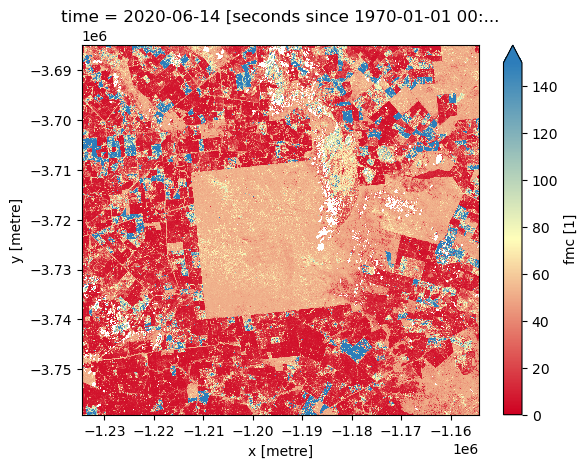

In [13]:
#plot the masked, loaded data
fmc_plot = ds_masked.fmc.isel(time=0).plot(cmap=cmap, vmin=0, vmax=150) #figsize=(9,6)

fmc_plot.colorbar.set_label('Fuel Moisture Content (Weight Percent)')

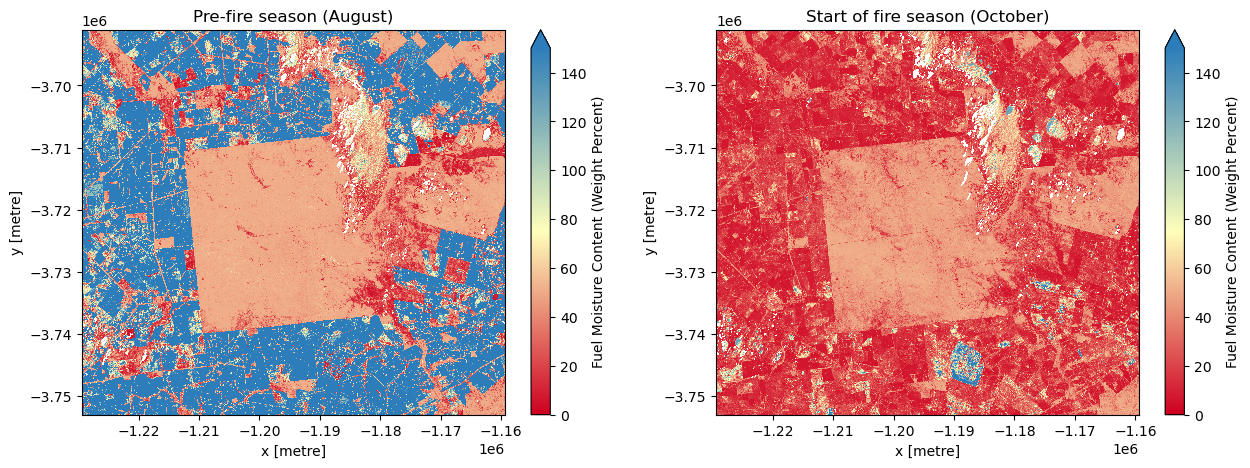

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
pre_fire_season = ds_masked.fmc.isel(time=0).plot(ax=ax[0], cmap=cmap, vmin=0, vmax=150) #add_colorbar=False
fire_season = ds_masked.fmc.isel(time=-1).plot(ax=ax[1], cmap=cmap, vmin=0, vmax=150)
pre_fire_season.colorbar.set_label('Fuel Moisture Content (Weight Percent)')
fire_season.colorbar.set_label('Fuel Moisture Content (Weight Percent)')
ax[0].set_title("Pre-fire season (August)")
ax[1].set_title("Start of fire season (October)");

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last modified:** August 2025

**Compatible datacube version:** 

In [12]:
print(datacube.__version__)

1.8.19


## Tags
<!-- Browse all available tags on the DEA User Guide's [Tags Index](https://knowledge.dea.ga.gov.au/genindex/) -->